In [117]:
#from google.colab import drive
#drive.mount('/content/drive')

In [118]:
import sys
#sys.path.append(r"C:\Users\Michael Ocampo\Documents\P_Files\opensees\final_\functions")
sys.path.append(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\functions")

In [119]:
#!sudo apt update
#!sudo apt install libglu1-mesa libglu1-mesa-dev
#!pip install -r requirements.txt

In [120]:
import openseespy.opensees as ops
import opsvis as opsv
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
import time
import gmsh
import solver_function as SF
import materialParam as param
import RCs_section as RCS
import importlib
importlib.reload(SF)
importlib.reload(param)
importlib.reload(RCS)
from solver_function import *
from materialParam import *
from RCs_section import *

In [121]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (101216642818)>


In [122]:
#
# Test Parameters − Consolidation Stage
#
vConf = -187  # Vertical confining pressure
hConf = -90  # Horizontal confining pressure
#
# Test Parameters − Shearing Stage
#
devDisp = -0.1  # Imposed vertical displacement
#
# Material parameters
#
rhoS = 1.8  # Saturated soil mass density
Gr = 1e5  # Reference Shear modulus
Kr = 1.7e5  # Reference Bulk modulus
phi = 35.5  # Peak friction angle
gamax = 0.085  # Peak shear strain
pr = 100  # Reference mean effective pressure
D = 0.5  # Pressure dependence coefficient
PT = 31  # Phase Trasformation angle
c1 = 0.125  # Const for contraction
c3 = 1  # Const for contraction
d1 = 0.25  # Const for dilation
d3 = 5.7  # Const for dilation
NYS = 30  # Number of Yield Surfaces
c2 = 0.5  # Const for contraction
d2 = 3.9  # Const for dilation
l1 = 1.95  # Damage Parameter
l2 = 0  # Damage Parameter
Bf = 2.2e6  # Fluid bulk modulus
e = 0.9  # Soil void ratio
n = e / (1 + e)  # Soil porosity
Bc = Bf / n  # Combined bulk modulus
perm = 1e-16  # Perm. −undrained response−
#
# Rayleigh damping parameters
#
damp = 0.1
omega1 = 0.0157
omega2 = 64.123
a1 = 2.0 * damp / (omega1 + omega2)
a0 = a1 * omega1 * omega2
#
#
import openseespy.opensees as ops
import time
#
ops.wipe()
#
ops.model('BasicBuilder', '-ndm', 3, '-ndf', 4)
#
# Material Definition
#
ops.nDMaterial('PressureDependMultiYield02', 1, 3, rhoS, Gr, Kr, phi,
               gamax, pr, D, PT, c1, c3, d1, d3, NYS, c2, d2, l1, l2, e)
#
# Nodes Definition
#
ops.node(1, 1.0, 0.0, 0.0)
ops.node(2, 1.0, 1.0, 0.0)
ops.node(3, 0.0, 1.0, 0.0)
ops.node(4, 0.0, 0.0, 0.0)
ops.node(5, 1.0, 0.0, 1.0)
ops.node(6, 1.0, 1.0, 1.0)
ops.node(7, 0.0, 1.0, 1.0)
ops.node(8, 0.0, 0.0, 1.0)
#
# Fixities Definition
#
ops.fix(1, 0, 1, 1, 1)
ops.fix(2, 0, 0, 1, 1)
ops.fix(3, 1, 0, 1, 1)
ops.fix(4, 1, 1, 1, 1)
ops.fix(5, 0, 1, 0, 1)
ops.fix(6, 0, 0, 0, 1)
ops.fix(7, 1, 0, 0, 1)
ops.fix(8, 1, 1, 0, 1)
#
# Finite Element creation
#
ops.element('SSPbrickUP', 1, 1, 2, 3, 4, 5, 6, 7, 8, 1, Bc, 1, perm, perm, perm, e, 1.5e-9)
#
# Output definition
#

ops.recorder('Node', '-file', 'disp1_man.out', '-time', '-node', 1, 2, 3, 4, 5, 6, 7, 8,'-dof', 1, 'disp')
ops.recorder('Node', '-file', 'disp2_man.out', '-time', '-node', 1, 2, 3, 4, 5, 6, 7, 8,'-dof', 2, 'disp')
ops.recorder('Node', '-file', 'pressure_man.out', '-time', '-node', 8, '-dof', 3, 'vel')
ops.recorder('Element', '-file', 'stress_man.out', '-time', '-ele', 1, 'stress')  # s11 s22 s33 s12 eta (EFFECTIVE stresses)
ops.recorder('Element', '-file', 'strain_man.out', '-time', '-ele', 1, 'strain')  # e11 e22 gama12 (it is not e33 nor e12)
ops.recorder('Element', '-file', 'backbone_man.out', '-ele', 1, 'backbone', 100, 1600)
#
# Define analysis parameters
#
ops.constraints('Penalty', 1e18, 1e18)
ops.test('NormDispIncr', 1e-4, 50, 2)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.system('BandGeneral')
ops.integrator('Newmark', 0.5, 0.25)
ops.rayleigh(a0, 0, a1, 0)
ops.analysis('Transient')
#
startT = time.time()
#
#======================================================#
# Stage 1 − Consolidation Procedure #
#======================================================#
vNode = vConf / 4.0
hNode = hConf / 4.0
#
ops.timeSeries('Series', 1, '-time', 0, 500, 10000, '-values', 0, 1, 1)
ops.pattern('Plain', 1, 1)
ops.load(1, hNode, 0, 0, 0)
ops.load(2, hNode, hNode, 0, 0)
ops.load(3, 0, hNode, 0, 0)
ops.load(4, 0, 0, 0, 0)
ops.load(5, hNode, 0, vNode, 0)
ops.load(6, hNode, hNode, vNode, 0)
ops.load(7, 0, hNode, vNode, 0)
ops.load(8, 0, 0, vNode, 0)
#
ops.analyze(500, 1.0)
print('')
print('Consolidation procedure − done.')
print('')
#
# Let the model rest and waves damp out
#
ops.analyze(50, 1.0)
ODB = opst.post.CreateODB(
    odb_tag='ctc_normal',
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)
#
#======================================================#
# Stage 2 − Deviatoric Strain #
#======================================================#
#
# Drainage closure
#
for x in range(1, 9):
    ops.remove('sp', x, 4)
#
ops.analyze(50, 1.0)
#
# Keep consolidation pressure applied and set analysis time
#
ops.loadConst('-time', 600.0)
#
# Switch the material to plastic
#
ops.updateMaterialStage('-material', 1, '-stage', 1)
#
# Define loading parameter
#
vDisp = ops.nodeDisp(5, 3)
lvalues = [1, 1 + devDisp / vDisp, 1 + devDisp / vDisp]
#
ops.timeSeries('Series', 3, '-time', 600, 300600, 1000000, '-values', *lvalues, '-factor', 1.0)
ops.pattern('Plain', 3, 3)
ops.sp(5, 3, vDisp)
ops.sp(6, 3, vDisp)
ops.sp(7, 3, vDisp)
ops.sp(8, 3, vDisp)
#
npts, dT = 3000, 100
for _ in range(npts):
    ops.analyze(1, dT)
    ODB.fetch_response_step()
    
ODB.save_response(zlib=True)
#
endT = time.time()
print('')
print('Horizontal Shear − done.')
print(f'Execution time: {endT - startT} seconds.')
print('')
# 
#ops.wipe()


Consolidation procedure − done.



CTestNormDispIncr::test() - iteration: 1 current Norm: 2.28158e-06 (max: 0.0001, Norm deltaR: 9.56461e-17)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.30997e-06 (max: 0.0001, Norm deltaR: 7.34344e-17)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.28182e-06 (max: 0.0001, Norm deltaR: 4.13549e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.30973e-06 (max: 0.0001, Norm deltaR: 7.49914e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.28206e-06 (max: 0.0001, Norm deltaR: 4.34443e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.30949e-06 (max: 0.0001, Norm deltaR: 5.11788e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.28229e-06 (max: 0.0001, Norm deltaR: 6.56817e-16)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.30926e-06 (max: 0.0001, Norm deltaR: 1.27796e-15)
CTestNormDispIncr::test() - iteration: 1 current Norm: 2.28253e-06 (max: 0.0001, Norm deltaR: 7.21645e-16)
CTestNormDispIncr::test() - iteration

OPSTOOL ::  All responses data with _odb_tag = ctc_normal saved in .opstool.output/RespStepData-ctc_normal.nc!


Horizontal Shear − done.
Execution time: 7.4490015506744385 seconds.



In [123]:
node_resp = opst.post.get_nodal_responses(odb_tag='ctc_normal')
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-ctc_normal.nc ...

<xarray.Dataset> Size: 4MB
Dimensions:             (time: 3001, nodeTags: 8, DOFs: 6)
Coordinates:
  * time                (time) float32 12kB 0.0 700.0 ... 3.005e+05 3.006e+05
  * nodeTags            (nodeTags) int64 64B 1 2 3 4 5 6 7 8
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 576kB -7.82e-05 ... 3....
    vel                 (time, nodeTags, DOFs) float32 576kB -1.203e-07 ... 0...
    accel               (time, nodeTags, DOFs) float32 576kB 3.205e-05 ... 0.126
    reaction            (time, nodeTags, DOFs) float32 576kB 8.036e-05 ... 0.0
    reactionIncInertia  (time, nodeTags, DOFs) float32 576kB -3.553e-15 ... 0.0
    rayleighForces      (time, nodeTags, DOFs) float32 576kB -8.757e-05 ... 0.0
    pressure            (time, nodeTags) float32 96kB 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction
    UZ:       Displac

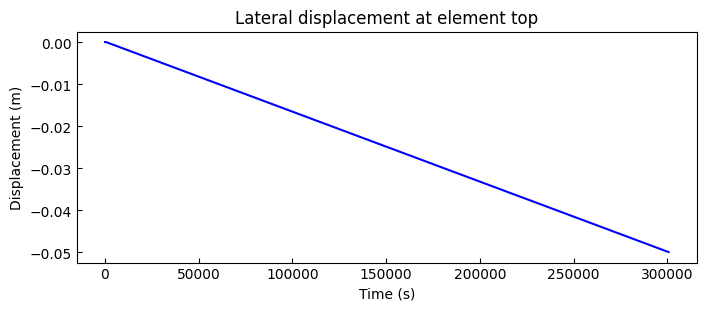

In [124]:
disp1 = node_resp["disp"].sel(nodeTags=1, DOFs="UX")
disp3 = node_resp["disp"].sel(nodeTags=3, DOFs="UX")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp3 - disp1, "b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

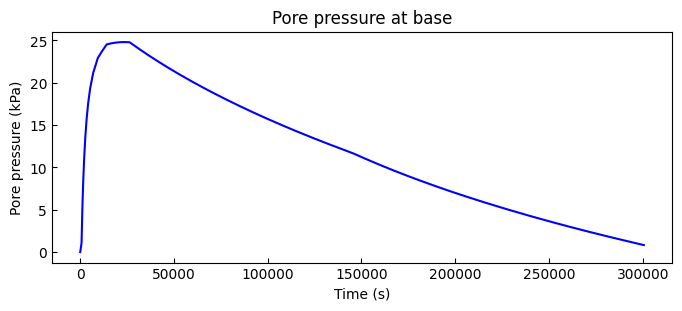

In [125]:
p1 = node_resp["vel"].sel(nodeTags=1, DOFs="RZ")

fig, ax = plt.subplots(1, 1, figsize=(8, 3))

ax.plot(times, p1, "b")
ax.set_title("Pore pressure at base")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pore pressure (kPa)")
plt.show()

In [126]:
ele_resp = opst.post.get_element_responses(odb_tag='ctc_normal', ele_type="Brick")
print("Data Variables in Element Responses:", ele_resp.data_vars)

OPSTOOL ::  Loading Brick response data from .opstool.output/RespStepData-ctc_normal.nc ...

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 84kB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 72kB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 672kB 0.0 ......
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 576kB 0.0 ......
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 672kB 0.0 ......
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 576kB 0.0 ......
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 84kB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 84kB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 672kB 0.0 ... 0.0
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 672kB 0.0 ... 0.0


In [127]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=1)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=1)
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=1)
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=1)
eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=1)

In [128]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 3001, GaussPoints: 1)> Size: 12kB
array([[ -45.72603 ],
       [  46.814323],
       [  47.769558],
       ...,
       [-116.60509 ],
       [-116.61178 ],
       [ 116.618484]], shape=(3001, 1), dtype=float32)
Coordinates:
  * time         (time) float32 12kB 0.0 700.0 800.0 ... 3.005e+05 3.006e+05
    eleTags      int64 8B 1
  * GaussPoints  (GaussPoints) int64 8B 1
    stressDOFs   <U7 28B 'sigma12'


In [129]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=1)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=1)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=1)

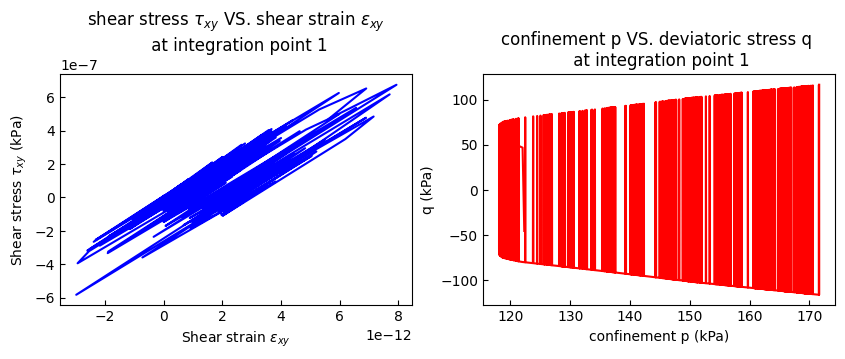

In [130]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(-po_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

In [131]:
print("Dimensions:", ele_resp["StressesAtNodes"].dims)
print("Coords: ", ele_resp["StressesAtNodes"].coords)

Dimensions: ('time', 'nodeTags', 'stressDOFs')
Coords:  Coordinates:
  * time        (time) float32 12kB 0.0 700.0 800.0 ... 3.005e+05 3.006e+05
  * stressDOFs  (stressDOFs) <U7 196B 'sigma11' 'sigma22' ... 'sigma13' 'eta_r'
  * nodeTags    (nodeTags) int64 64B 1 2 3 4 5 6 7 8


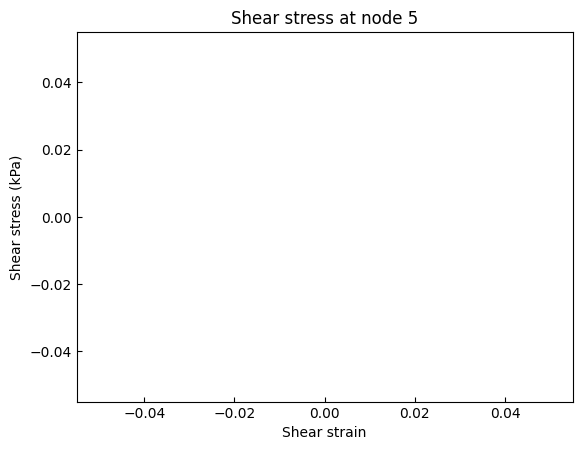

In [132]:
sxy5 = ele_resp["StressesAtNodes"].sel(stressDOFs="sigma12", nodeTags=1)
exy5 = ele_resp["StrainsAtNodes"].sel(strainDOFs="eps12", nodeTags=1)

plt.plot(exy5, sxy5, "b")
plt.title("Shear stress at node 5")
plt.xlabel("Shear strain")
plt.ylabel("Shear stress (kPa)")
plt.show()